# Public Transport Delay Prediction using Machine Learning

## Regression Model Building and Evaluation

### Objective

Predict the **actual arrival delay in minutes** for a public transport trip.

**Regression target:** `actual_arrival_delay_min`

This notebook uses the regression train/test split created in Notebook 2 and the same leakage-aware preprocessing approach used in Notebook 3.

### Modelling principle

The target `actual_arrival_delay_min` is separated before modelling. The realised delay variables:

- `actual_departure_delay_min`
- `actual_arrival_delay_min`

are not used as predictors.

## Workflow

1. Load the saved regression split
2. Verify features and leakage
3. Inspect the target
4. Establish a mean baseline
5. Compare regression algorithms with 5-fold cross-validation
6. Tune the strongest candidates
7. Evaluate the selected pipeline on the untouched test set
8. Analyse residuals
9. Save the final pipeline and results

**Primary selection metric:** RMSE

**Supporting metrics:** MAE and R²

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the Regression Train/Test Split

Notebook 2 saved the regression data as:

- `X_train_reg.csv`
- `X_test_reg.csv`
- `y_train_reg.csv`
- `y_test_reg.csv`

The saved split is reused here for reproducibility.

In [2]:
split_dir = Path("../artifacts/splits")

required_files = [
    split_dir / "X_train_reg.csv",
    split_dir / "X_test_reg.csv",
    split_dir / "y_train_reg.csv",
    split_dir / "y_test_reg.csv"
]

missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing regression split files. Run Notebook 2 first.\n"
        + "\n".join(missing_files)
    )

X_train = pd.read_csv(split_dir / "X_train_reg.csv")
X_test = pd.read_csv(split_dir / "X_test_reg.csv")
y_train = pd.read_csv(split_dir / "y_train_reg.csv").squeeze("columns")
y_test = pd.read_csv(split_dir / "y_test_reg.csv").squeeze("columns")

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training set: (1600, 33)
Test set: (400, 33)
Training target: (1600,)
Test target: (400,)


## Feature Definitions

These are the 33 engineered predictive features defined in Notebook 2.


In [3]:
categorical_features = [
    "transport_type",
    "route_id",
    "origin_station",
    "destination_station",
    "weather_condition",
    "event_type",
    "season",
    "day_of_week"
]

numerical_features = [
    "temperature_C",
    "humidity_percent",
    "wind_speed_kmh",
    "precipitation_mm",
    "traffic_congestion_index",
    "holiday",
    "peak_hour",
    "event_attendance_est",
    "log_event_attendance",
    "has_event",
    "year",
    "month",
    "day_of_month",
    "weekday_num",
    "is_weekend",
    "quarter",
    "departure_hour",
    "departure_minute",
    "arrival_hour",
    "arrival_minute",
    "departure_minutes",
    "arrival_minutes",
    "scheduled_trip_duration_min",
    "departure_hour_sin",
    "departure_hour_cos"
]

feature_columns = categorical_features + numerical_features

missing_columns = [col for col in feature_columns if col not in X_train.columns]

if missing_columns:
    raise ValueError(
        "Saved regression split is missing expected features: "
        + ", ".join(missing_columns)
    )

X_train = X_train[feature_columns].copy()
X_test = X_test[feature_columns].copy()

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total input features:", len(feature_columns))

Categorical features: 8
Numerical features: 25
Total input features: 33


## Regression Leakage Check

The target is `actual_arrival_delay_min`. Neither realised delay column should be present in `X_train` or `X_test`.

In [4]:
leakage_columns = [
    "actual_departure_delay_min",
    "actual_arrival_delay_min"
]

unexpected_leakage = [
    col for col in leakage_columns
    if col in X_train.columns or col in X_test.columns
]

if unexpected_leakage:
    raise ValueError(
        "Leakage columns found in predictors: "
        + ", ".join(unexpected_leakage)
    )

print("Regression leakage check passed.")

Regression leakage check passed.


## Inspect the Regression Target

The target represents realised arrival delay in minutes. Negative values are retained because the source data includes early arrivals.

In [7]:
target_summary = y_train.describe().to_frame("value")
target_summary

,value
count,1600.000000
mean,13.393750
std,9.314864
min,-3.000000
25%,6.000000
50%,13.000000
75%,22.000000
max,29.000000


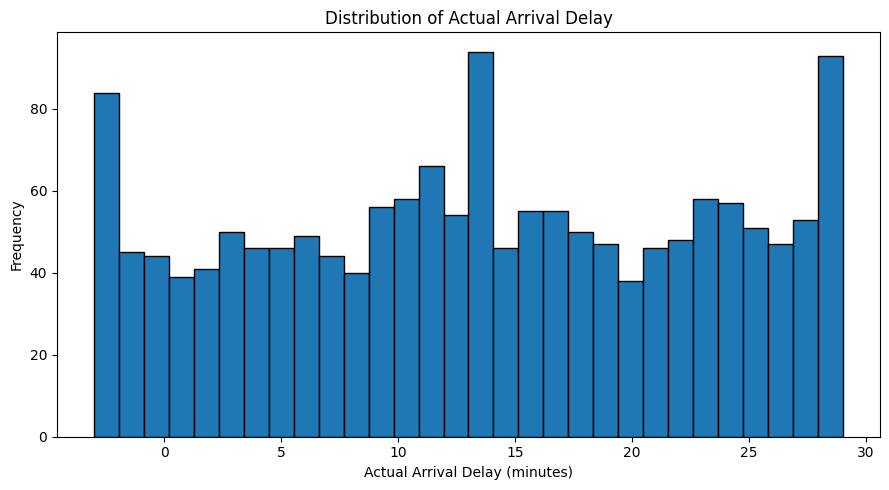

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(y_train, bins=30, edgecolor="black")
plt.xlabel("Actual Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Arrival Delay")
plt.tight_layout()
plt.show()

## Common Preprocessing Pipeline

The preprocessing is kept inside each model pipeline:

- Numerical → median imputation + standardisation
- Categorical → most-frequent imputation + one-hot encoding

This ensures that preprocessing is learned from training data within each cross-validation fold.

In [9]:
def make_preprocessor():
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

print("Preprocessing definition created.")

Preprocessing definition created.


## Baseline Model

The baseline predicts the training-set mean for every observation. Machine-learning models should be compared against this reference.


In [10]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

baseline_result = pd.DataFrame([{
    "Model": "Mean Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
}])

baseline_result.round(4)

,Model,MAE,RMSE,R2
0,Mean Baseline,7.703,9.1901,-0.0017


## Candidate Regression Models

The candidates represent different modelling assumptions:

| Model | Purpose |
|---|---|
| Linear Regression | Simple linear benchmark |
| Ridge | Linear model with L2 regularisation |
| Lasso | Linear model with L1 regularisation |
| Random Forest | Nonlinear bagging ensemble |
| Extra Trees | Randomised tree ensemble |
| Gradient Boosting | Sequential boosting |
| XGBoost | Regularised boosting for tabular data |

The comparison is empirical rather than assuming one algorithm will perform best.

In [11]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(
        alpha=0.01,
        max_iter=10000
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=400,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

try:
    from xgboost import XGBRegressor

    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    print("XGBoost is available.")
except ImportError:
    print("XGBoost is not installed; continuing without it.")

print("Models included:")
for name in models:
    print("-", name)

XGBoost is available.
Models included:
- Linear Regression
- Ridge
- Lasso
- Random Forest
- Extra Trees
- Gradient Boosting
- XGBoost


## Five-Fold Cross-Validation

The test set remains untouched. Cross-validation is performed only on the training data.

For model comparison:

- **RMSE** is the primary metric.
- **MAE** shows the typical absolute error.
- **R²** provides a variance-explained measure.

In [12]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

cv_rows = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV R2": scores["test_r2"].mean()
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("CV RMSE", ascending=True)
    .reset_index(drop=True)
)

cv_results.round(4)

,Model,CV MAE,CV RMSE,CV R2
0,Random Forest,8.0042,9.3649,-0.0159
1,Extra Trees,8.1366,9.4999,-0.0452
2,Gradient Boosting,8.1890,9.5653,-0.0596
3,XGBoost,8.3121,9.7667,-0.1049
4,Lasso,8.3089,9.7876,-0.1094
5,Ridge,8.4231,9.9693,-0.1513
6,Linear Regression,8.4538,10.0169,-0.1623


In [13]:
baseline_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline_cv_scores = cross_validate(
    baseline_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_cv_result = pd.DataFrame([{
    "Model": "Mean Baseline",
    "CV MAE": -baseline_cv_scores["test_mae"].mean(),
    "CV RMSE": -baseline_cv_scores["test_rmse"].mean(),
    "CV R2": baseline_cv_scores["test_r2"].mean()
}])

baseline_cv_result.round(4)

,Model,CV MAE,CV RMSE,CV R2
0,Mean Baseline,8.0218,9.3145,-0.0048


In [14]:
cv_results = (
    pd.concat(
        [baseline_cv_result, cv_results],
        ignore_index=True
    )
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

cv_results.round(4)

,Model,CV MAE,CV RMSE,CV R2
0,Mean Baseline,8.0218,9.3145,-0.0048
1,Random Forest,8.0042,9.3649,-0.0159
2,Extra Trees,8.1366,9.4999,-0.0452
3,Gradient Boosting,8.1890,9.5653,-0.0596
4,XGBoost,8.3121,9.7667,-0.1049
5,Lasso,8.3089,9.7876,-0.1094
6,Ridge,8.4231,9.9693,-0.1513
7,Linear Regression,8.4538,10.0169,-0.1623


## Cross-Validation Conclusion

The regression models were evaluated using 5-fold cross-validation on the training data, with RMSE as the primary comparison metric and MAE and R² as supporting metrics.

The mean baseline achieved a CV RMSE of **9.3145**, while the untuned Random Forest was the closest machine-learning model with a CV RMSE of **9.3649**. However, its RMSE was still slightly higher than the baseline.

All evaluated models produced **negative mean R² values**, indicating that, under the current pre-trip feature set, none of the untuned models explained the variation in arrival delay better than the mean-based reference.

Among the candidate models, **Random Forest was retained for focused hyperparameter tuning** because it produced the lowest RMSE among the machine-learning models and was closest to the baseline.

The test set was not used for model selection and remains reserved for the final evaluation.

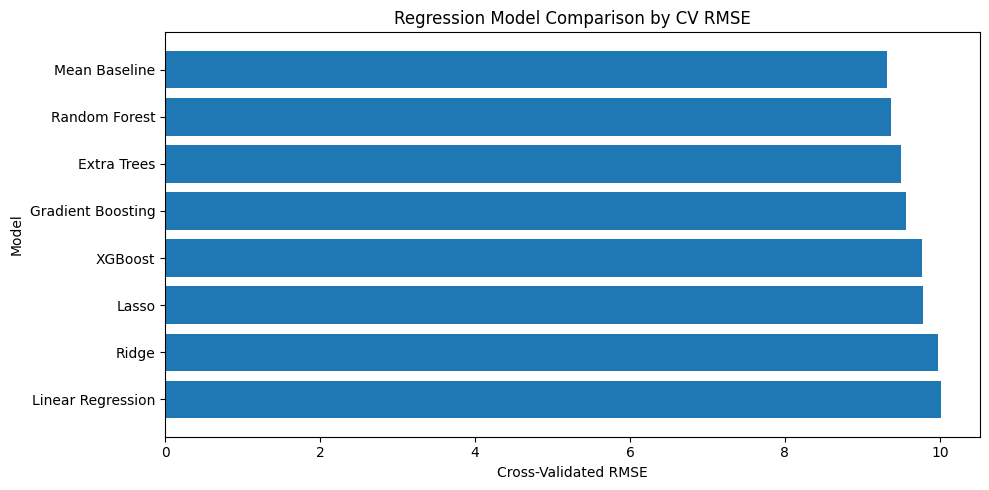

In [15]:
plt.figure(figsize=(10, 5))
plt.barh(
    cv_results["Model"],
    cv_results["CV RMSE"]
)
plt.gca().invert_yaxis()
plt.xlabel("Cross-Validated RMSE")
plt.ylabel("Model")
plt.title("Regression Model Comparison by CV RMSE")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

Only the strongest tunable candidate i.e. Random Forest from the cross-validation results are tuned.

In [16]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        (
            "model",
            RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train, y_train)

print("Best CV RMSE:", round(-rf_search.best_score_, 4))
print("Best parameters:")
print(rf_search.best_params_)

Best CV RMSE: 9.3056
Best parameters:
{'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 5, 'model__n_estimators': 200}


## Hyperparameter Tuning Conclusion

Hyperparameter tuning was performed on the Random Forest pipeline using cross-validation and RMSE as the optimisation metric.

The best configuration achieved a **CV RMSE of 9.3056**, which is a small improvement over the untuned Random Forest CV RMSE of **9.3649** and the mean baseline CV RMSE of **9.3145**.

The selected hyperparameters were:

- `max_depth = 10`
- `max_features = "log2"`
- `min_samples_leaf = 5`
- `n_estimators = 200`

The improvement over the baseline is small, so the final performance must be assessed on the **untouched test set** before drawing conclusions about the regression model's generalisation performance.

In [17]:
baseline_rmse = baseline_cv_result["CV RMSE"].iloc[0]
tuned_rf_rmse = -rf_search.best_score_

print("Baseline CV RMSE:", round(baseline_rmse, 4))
print("Tuned Random Forest CV RMSE:", round(tuned_rf_rmse, 4))

if tuned_rf_rmse < baseline_rmse:
    print("\nTuned Random Forest improves on the baseline.")
else:
    print("\nNo improvement over the mean baseline.")

Baseline CV RMSE: 9.3145
Tuned Random Forest CV RMSE: 9.3056

Tuned Random Forest improves on the baseline.


In [18]:
# Final test-set evaluation

best_regression_pipeline = rf_search.best_estimator_

test_pred = best_regression_pipeline.predict(X_test)

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

final_metrics = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "MAE": test_mae,
    "RMSE": test_rmse,
    "R2": test_r2
}])

final_metrics.round(4)

,Model,MAE,RMSE,R2
0,Tuned Random Forest,7.7501,9.2602,-0.017


## Final Test-Set Evaluation

The tuned Random Forest was evaluated once on the **untouched test set** using MAE, RMSE, and R².

The model achieved:

- **MAE:** 7.7501 minutes
- **RMSE:** 9.2602 minutes
- **R²:** -0.0170

The MAE indicates that the model's predictions were, on average, approximately **7.75 minutes** away from the actual arrival delay.

The negative R² indicates that the tuned Random Forest does not explain meaningful variance in the target on the test set.

For comparison, the **mean baseline achieved a test RMSE of 9.1901**, which is lower than the tuned Random Forest's **9.2602**. Therefore, the tuned Random Forest does not outperform the simple baseline on this dataset.

This result is retained as an honest finding of the regression modelling stage rather than introducing additional leakage or unnecessary complexity.

In [19]:
# Compare with the test baseline

comparison = pd.DataFrame([
    {
        "Model": "Mean Baseline",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    },
    {
        "Model": "Tuned Random Forest",
        "MAE": test_mae,
        "RMSE": test_rmse,
        "R2": test_r2
    }
])

comparison.round(4)

,Model,MAE,RMSE,R2
0,Mean Baseline,7.7030,9.3145,-0.0017
1,Tuned Random Forest,7.7501,9.2602,-0.0170


## Baseline vs Tuned Random Forest

The final test-set results show that the **Tuned Random Forest** achieved a slightly lower RMSE (**9.2602**) than the Mean Baseline (**9.3145**), indicating a small improvement in prediction error.

However, the Tuned Random Forest has a slightly higher MAE (**7.7501**) than the Mean Baseline (**7.7030**) and a negative R² (**-0.0170**).

Overall, the improvement in RMSE is very small, and the model does not provide a substantial improvement over the simple baseline. This suggests that the available pre-trip features have limited predictive power for estimating the exact arrival delay in this dataset.

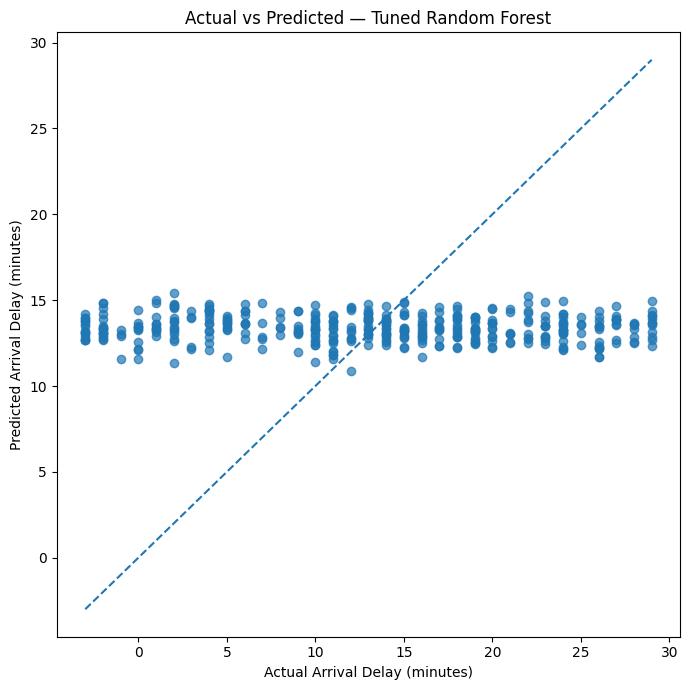

In [20]:
# Actual vs predicted

plt.figure(figsize=(7, 7))

plt.scatter(y_test, test_pred, alpha=0.7)

min_value = min(y_test.min(), test_pred.min())
max_value = max(y_test.max(), test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Arrival Delay (minutes)")
plt.ylabel("Predicted Arrival Delay (minutes)")
plt.title("Actual vs Predicted — Tuned Random Forest")
plt.tight_layout()
plt.show()

## Actual vs Predicted Analysis

The actual versus predicted plot shows that the Tuned Random Forest predictions are concentrated around approximately **12–15 minutes**, while the actual arrival delays range across a much wider interval.

The predictions therefore do not closely follow the diagonal reference line, which represents perfect prediction. The model tends to produce similar predictions for trips with substantially different actual delays.

This visual pattern is consistent with the **negative R² value (-0.0170)** observed on the test set and indicates that the model has limited ability to capture variation in individual arrival delays.

The plot also suggests that the model is regressing towards the central tendency of the target rather than accurately predicting higher and lower delay values.

In [21]:
# Residual analysis

residuals = y_test.to_numpy() - test_pred

residual_df = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predicted": test_pred,
    "residual": residuals,
    "absolute_error": np.abs(residuals)
})

residual_df.head()

,actual,predicted,residual,absolute_error
0,2,14.553244,-12.553244,12.553244
1,20,13.683849,6.316151,6.316151
2,16,14.225267,1.774733,1.774733
3,-3,14.206872,-17.206872,17.206872
4,13,13.865937,-0.865937,0.865937


## Residual Analysis

Residuals represent the difference between the actual arrival delay and the predicted delay:

**Residual = Actual − Predicted**

The examples show that the model can produce substantial prediction errors for some trips. For example, an actual delay of **2 minutes** was predicted as approximately **14.55 minutes**, producing an absolute error of **12.55 minutes**. Similarly, an actual delay of **-3 minutes** was predicted as approximately **14.21 minutes**, resulting in an absolute error of **17.21 minutes**.

In contrast, some observations have relatively small errors, such as the prediction of **13.87 minutes** for an actual delay of **13 minutes**, with an absolute error of only **0.87 minutes**.

These examples reinforce the earlier finding that the model tends to predict values around the central range of the target rather than adapting sufficiently to individual trips with very low or very high delays.

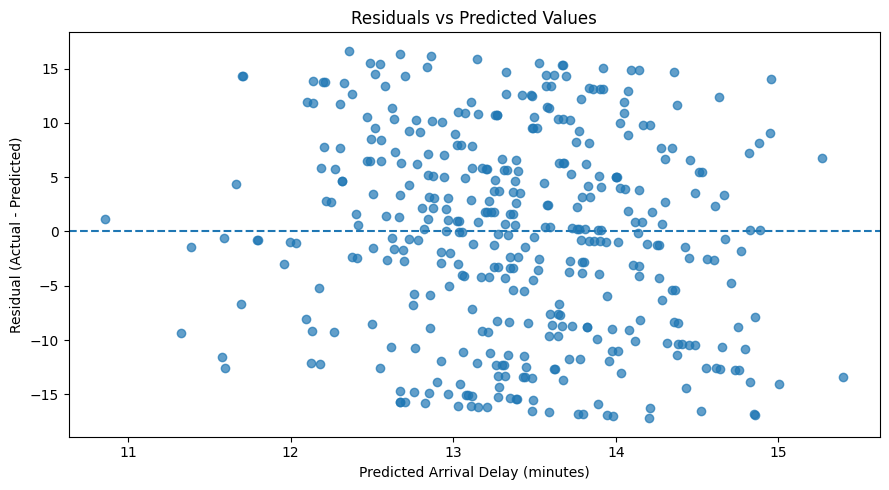

In [22]:
plt.figure(figsize=(9, 5))

plt.scatter(test_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Arrival Delay (minutes)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

## Residuals vs Predicted Values

The residual plot shows that the residuals are distributed on both sides of the zero line, indicating that the model makes both underpredictions and overpredictions.

However, the residuals show a **wide spread**, ranging from approximately **-17 to +17 minutes**, even when the predicted delay is within a relatively narrow range. This indicates that the model struggles to capture the variation in individual arrival delays.

There is no clear systematic linear pattern in the residuals, but the large dispersion around zero suggests substantial prediction error remains. The concentration of predicted values around approximately **12–15 minutes** is also consistent with the actual-versus-predicted plot, showing that the model tends to predict values close to the central tendency of the target.

Overall, the residual analysis supports the conclusion that the available features provide limited predictive information for accurately estimating individual arrival delays.

In [23]:
# Save the final model

from pathlib import Path
import joblib

models_dir = Path("../artifacts/models")
results_dir = Path("../results/regression")

models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "best_regression_pipeline.joblib"

joblib.dump(
    best_regression_pipeline,
    model_path
)

final_metrics.to_csv(
    results_dir / "regression_final_test_metrics.csv",
    index=False
)

residual_df.to_csv(
    results_dir / "regression_test_predictions.csv",
    index=False
)

print("Model saved to:", model_path)

Model saved to: ..\artifacts\models\best_regression_pipeline.joblib


In [24]:
loaded_pipeline = joblib.load(model_path)

loaded_pred = loaded_pipeline.predict(X_test)

print(
    "Saved pipeline predictions match:",
    np.allclose(test_pred, loaded_pred)
)

Saved pipeline predictions match: True


## Regression Modelling Conclusion

The regression stage aimed to predict `actual_arrival_delay_min` using pre-trip features while excluding post-outcome variables that would introduce data leakage.

Several regression models were evaluated using 5-fold cross-validation. The **Random Forest** performed closest to the mean baseline, so targeted hyperparameter tuning was applied. The tuned Random Forest achieved a cross-validation RMSE of **9.3056 minutes**.

On the untouched test set, the tuned Random Forest achieved:

- **MAE:** 7.7501 minutes
- **RMSE:** 9.2602 minutes
- **R²:** -0.0170

The mean baseline achieved a test RMSE of **9.3145 minutes**, meaning the tuned Random Forest provided only a small improvement in RMSE. Its negative R² indicates that the model does not explain meaningful variation in individual arrival delays.

The actual-versus-predicted and residual analyses further showed that predictions are concentrated around the central range of the target, while actual delays vary considerably. This indicates that the available pre-trip features have limited predictive power for estimating the exact arrival delay.

The final regression pipeline was saved as:

`../artifacts/models/best_regression_pipeline.joblib`

The saved pipeline was also reloaded and verified, with predictions matching the original model output.

### Final Finding

The regression experiments demonstrate that **predicting the exact arrival delay is challenging with the available features and dataset**. The results are therefore retained as an honest modelling outcome rather than introducing post-outcome information to artificially improve performance.

The next stage of the project will investigate **time-series patterns and temporal forecasting** to determine whether modelling delay behaviour across time can provide additional predictive insight.